# Part 3 — Application: Risk Segmentation and Classifying Ambiguous Records

**Project:** Privacy Risk Analysis and Automatic Classification in the GPT Plugin Ecosystem

**Research Question 4:** When we group plugins by the type of data they collect, do natural risky/safe clusters emerge? (clustering)

**Research Question 5:** Can the model we built in Part 2 be used to classify records with an ambiguous label (specifically the "Other" category in `data_type`, 3,544 records)?

**Plan for this section:**
1. Setting up the problem: moving from parameter-level to plugin-level — extracting each plugin's "data collection profile"
2. Clustering: grouping plugins by data collection profile, interpreting the clusters (is there a risky/safe split?)
3. Applying the Part 2 model to "Other" records, interpreting the results cautiously
4. Overall project summary

## Step 1 — Moving from Parameter-Level to Plugin-Level

In Parts 1 and 2, every row was a **parameter**. But Research Question 4 wants to group plugins (GPT Actions) — meaning we need to change our unit of analysis from parameter to **plugin**.

**Challenge:** `plugin_id_filenames` is a list — the same parameter can be used by multiple plugins (e.g. a common "user_id" parameter might appear in hundreds of plugins). To handle this, we'll "explode" the data: each (plugin, parameter) pair becomes its own row. This lets us answer "which parameters/categories does this plugin collect?"

**How we derive a plugin's profile:** for each plugin, we'll compute the **proportion** of its parameters that fall into each category (e.g. "30% of this plugin's parameters are Identifier, 10% Security credentials..."). We use a proportion, not a raw count — because plugins vary hugely in size (from 1 parameter to 1000+); what matters is not the plugin's size but *the profile of what it collects*.

**Minimum parameter threshold:** a plugin with only 1-2 parameters would have a meaningless "profile" (it would appear 100% in one category, which is chance, not a pattern). So we'll only keep plugins with at least **3 parameters** — this leaves us **3,041** out of 4,592 plugins, a large enough sample.

In [1]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

DATA_PATH = '../backend/data/data_entries_final.json'

with open(DATA_PATH, 'r', encoding='utf-8') as f:
    raw_data = json.load(f)

df = pd.DataFrame(raw_data)
df['text'] = (df['name'].fillna('') + '. ' + df['description'].fillna('')).str.strip()

df_exploded = df.explode('plugin_id_filenames').rename(columns={'plugin_id_filenames': 'plugin_id'}).reset_index(drop=True)

print('Parameter record count:', len(df))
print('(plugin, parameter) row count after exploding:', len(df_exploded))
print('Unique plugin count:', df_exploded['plugin_id'].nunique())

Parameter record count: 12811
(plugin, parameter) row count after exploding: 40261
Unique plugin count: 4592


In [2]:
MIN_PARAMS = 3

plugin_param_counts = df_exploded.groupby('plugin_id').size()
eligible_plugins = plugin_param_counts[plugin_param_counts >= MIN_PARAMS].index

df_exploded_filtered = df_exploded[df_exploded['plugin_id'].isin(eligible_plugins)]

plugin_category_counts = pd.crosstab(df_exploded_filtered['plugin_id'], df_exploded_filtered['main_data_type'])
plugin_profile = plugin_category_counts.div(plugin_category_counts.sum(axis=1), axis=0)

print(f'Plugins with {MIN_PARAMS}+ parameters: {len(plugin_profile)}')
print('Profile matrix shape:', plugin_profile.shape)
plugin_profile.head(3)

Plugins with 3+ parameters: 3041
Profile matrix shape: (3041, 25)


main_data_type,App metadata,App usage data,E-commerce data,Event information,Files and documents,Finance information,Food and nutrition information,Gaming data,Health information,Identifier,Legal and law enforcement data,Location,Market data,Message,Other,Personal information,Query,Real estate data,Security credentials,Sports information,Time,Travel information,Vehicle information,Weather information,Web and network data
plugin_id,,,,,,,,,,,,,,,,,,,,,,,,,
g-009xFjOLC_OoDqO0qGP1tw2zGRYCYIfpUK,0.25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.25,0.0,0.0,0.25,0.0,0.0,0.0,0.0,0.0,0.0
g-00y8F1eRb_APoRCDy5ffgP0bHoQMuTHeML,0.00,0.7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.2,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.1
g-02IWjW9i4_gzm_cnf_brjSH6N13PZzuSsTMwtje1dt~gzm_tool_u3iT5JbQPY0dX8WI6dUjMMYB,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,1.00,0.0,0.0,0.00,0.0,0.0,0.0,0.0,0.0,0.0


## Step 2 — Clustering: How Many Natural Groups Are There?

**Intuition:** K-Means groups our 3,041 plugins into clusters by putting plugins with similar data-collection profiles (proportions across the 25 categories) together — with no labels given, purely by "which plugins resemble each other." Our goal: see whether one of these clusters comes out naturally "sensitive-data-heavy" (risky) and another "harmless/general-purpose" (safe).

**Standardization:** variance differs a lot across categories (e.g. the "Other" proportion varies a lot plugin to plugin, while "Health information" stays near zero for most plugins). Without standardizing, clustering would be shaped by just the 1-2 highest-variance categories. So we standardize every category (to mean 0, standard deviation 1) — so all 25 categories get an equal say in the clustering.

**How many clusters (K) to choose:** we don't guess this without looking at the data — we'll try several K values and look at the **silhouette score**. This score measures how well each plugin "belongs" to its own cluster versus how far it is from other clusters; a higher score means more clearly separated clusters.

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

scaler = StandardScaler()
profile_scaled = scaler.fit_transform(plugin_profile)

k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(profile_scaled)
    score = silhouette_score(profile_scaled, labels)
    silhouette_scores.append(score)
    print(f'K={k}: silhouette score = {score:.3f}')

K=2: silhouette score = 0.215
K=3: silhouette score = 0.211


K=4: silhouette score = 0.219


K=5: silhouette score = 0.216
K=6: silhouette score = 0.226


K=7: silhouette score = 0.227
K=8: silhouette score = 0.170


K=9: silhouette score = 0.237
K=10: silhouette score = 0.254


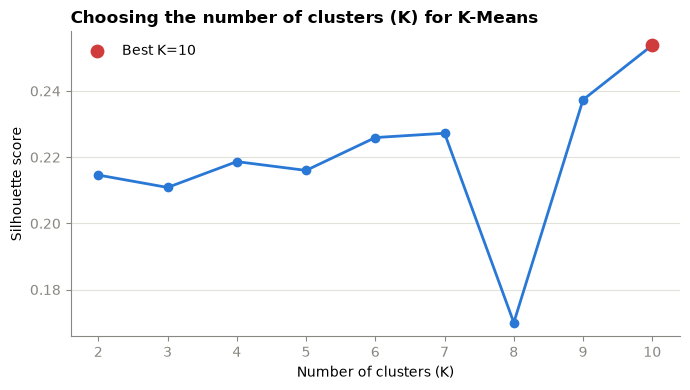

Selected K: 10 (silhouette score: 0.254)


In [4]:
COLOR_MAIN = '#2a78d6'
COLOR_MUTED = '#898781'
COLOR_TEXT = '#0b0b0b'

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(k_range), silhouette_scores, marker='o', color=COLOR_MAIN, linewidth=2, markersize=6)

best_k = list(k_range)[int(np.argmax(silhouette_scores))]
best_score = max(silhouette_scores)
ax.scatter([best_k], [best_score], color='#d03b3b', zorder=5, s=80, label=f'Best K={best_k}')

ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Silhouette score')
ax.set_title('Choosing the number of clusters (K) for K-Means', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq4_silhouette_scores.png', dpi=150, bbox_inches='tight')

plt.show()

print(f'Selected K: {best_k} (silhouette score: {best_score:.3f})')

In [5]:
final_kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
plugin_profile['cluster'] = final_kmeans.fit_predict(profile_scaled)

print(f'Plugin distribution across {best_k} clusters:')
print(plugin_profile['cluster'].value_counts().sort_index())

Plugin distribution across 10 clusters:
cluster
0    1523
1      83
2     338
3     154
4      14
5       3
6       5
7      11
8     891
9      19
Name: count, dtype: int64


### Finding (choosing K)

Two things are worth noting:

1. **Silhouette scores are low overall** (between 0.17 and 0.25) — this shows that plugins do not form clusters with clean, sharply separated data-collection profiles. This is actually expected: real-world data rarely splits into perfect clusters, and most plugins probably mix several categories.
2. The score generally rises as K increases, and the highest score is at K=10, but **cluster sizes are very unbalanced**: two large clusters (1523 and 891 plugins) cover most of the data, while the remaining 8 clusters are much smaller (some with only 3-19 plugins). These small clusters could be noise, but they could also be **very specific plugin groups concentrated on a single category** — we'll find out by looking at the cluster profiles in the next step.

For now we'll accept K=10 as the data-driven choice and move on; we'll decide whether the small clusters are meaningful or noise through profile analysis.

## Step 3 — Interpreting the Clusters: Is There a Risky/Safe Split?

We'll compute each cluster's "average profile" (centroid) and look at two things:
1. **What categories do the plugins in that cluster collect the most?** (top 3 dominant categories)
2. **What is that cluster's total share across the 4 sensitive categories** (Security credentials, Personal information, Health information, Finance information)? We'll call this the "sensitive share" and rank clusters by it.

If the answer to Research Question 4 is "yes," one or a few clusters with a high sensitive share should stand clearly apart from the low ones.

In [6]:
SENSITIVE_CATEGORIES = ['Security credentials', 'Personal information', 'Health information', 'Finance information']

centroids = plugin_profile.groupby('cluster').mean()
cluster_sizes = plugin_profile['cluster'].value_counts().sort_index()
sensitive_share = centroids[SENSITIVE_CATEGORIES].sum(axis=1)

cluster_summary = pd.DataFrame({
    'plugin_count': cluster_sizes,
    'sensitive_share': sensitive_share,
})
cluster_summary['dominant_categories'] = [
    ', '.join(f'{cat} (%{val*100:.0f})' for cat, val in centroids.loc[c].sort_values(ascending=False).head(3).items())
    for c in cluster_summary.index
]
cluster_summary = cluster_summary.sort_values('sensitive_share', ascending=False)
cluster_summary['sensitive_share'] = (cluster_summary['sensitive_share'] * 100).round(1)
cluster_summary

,plugin_count,sensitive_share,dominant_categories
cluster,,,
1,83,16.1,"Market data (%41), Time (%19), Finance informa..."
8,891,12.5,"Identifier (%22), Other (%18), App usage data ..."
5,3,10.5,"Real estate data (%45), Location (%16), App us..."
2,338,9.4,"Message (%21), Files and documents (%20), App ..."
6,5,4.2,"Food and nutrition information (%51), Query (%..."
4,14,3.4,"E-commerce data (%56), Identifier (%12), Web a..."
7,11,2.3,"Travel information (%42), Time (%21), Identifi..."
9,19,2.2,"Location (%37), Weather information (%27), App..."
0,1523,1.5,"App usage data (%49), Query (%22), Web and net..."


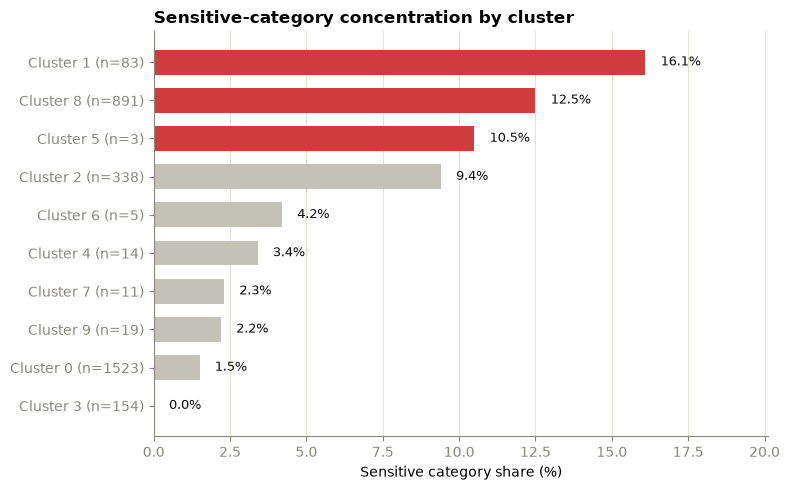

In [7]:
COLOR_SENSITIVE = '#d03b3b'
COLOR_NEUTRAL = '#c3c2b7'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

ordered = cluster_summary.sort_values('sensitive_share')
colors = [COLOR_SENSITIVE if v >= 10 else COLOR_NEUTRAL for v in ordered['sensitive_share']]
labels = [f'Cluster {c} (n={n})' for c, n in zip(ordered.index, ordered['plugin_count'])]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.barh(labels, ordered['sensitive_share'], color=colors, height=0.65)

for bar, val in zip(bars, ordered['sensitive_share']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f'{val:.1f}%',
            va='center', ha='left', fontsize=9, color=COLOR_TEXT)

ax.set_xlabel('Sensitive category share (%)')
ax.set_title('Sensitive-category concentration by cluster', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.set_xlim(0, ordered['sensitive_share'].max() * 1.25)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq4_cluster_sensitivity.png', dpi=150, bbox_inches='tight')

plt.show()

### Finding (Research Question 4)

The answer isn't a clear "yes," but it isn't a full "no" either — **a more nuanced picture emerges:**

- Instead of producing a clean binary split on the sensitive/non-sensitive axis, clustering surfaces **functional/thematic groups**: market & finance data (Cluster 1), everyday app usage (Cluster 0 — the largest cluster, 1523 plugins), identity/general-purpose (Cluster 8 — the second largest, 891 plugins), messaging & files (Cluster 2), travel (Cluster 7), e-commerce (Cluster 4), location & weather (Cluster 9), real estate (Cluster 5), food (Cluster 6), and a cluster that collects only app metadata (Cluster 3).
- The sensitive-category share is spread **gradually** across these clusters, with no sharp jump: highest at 16.1% (Cluster 1, market/finance-heavy but only 83 plugins), lowest at 0% (Cluster 3, which collects only "App metadata" and "Query," 154 plugins).
- **"Largest" and "riskiest" are different clusters** — worth not conflating: the two largest clusters (Cluster 0: 1523 plugins, Cluster 8: 891 plugins) together make up **~80%** of all plugins, but their sensitive shares are low-to-medium (1.5% and 12.5%). The two clusters with the highest sensitive share (Cluster 1: 16.1%, Cluster 8: 12.5%) together make up only **~32%** of all plugins (83+891=974 / 3041 plugins). Cluster 8 shows up in both rankings (both large and relatively risky); Cluster 1 is small but the riskiest; Cluster 0 is large but low-risk.

**Conclusion:** The natural clusters don't split into "risky vs. safe," but being able to **rank** clusters by sensitive-data density is itself a useful risk-segmentation tool — e.g. the plugins in Cluster 1 and Cluster 8 (the two clusters with the highest sensitive share, together ~32% of all plugins) can be flagged as the groups that most deserve review priority.

## Step 4 — Applying the Model to "Other" Records (Research Question 5)

**A critical methodology decision:** we can't just reuse Part 2's `data_type` model as-is, because it saw "Other" as a **valid class** during training. Here our goal is different: the "Other" label is already unreliable (it means ambiguous/unlabeled), so we shouldn't even tell the model "Other exists as a class" — otherwise the model will likely just predict "Other" for everything again, and we'll have learned nothing.

**Solution:** we'll retrain the model using **only the non-"Other"** 9,267 records, over the real 144 `data_type` values (again grouping rare classes, 77 usable classes + 1 rare bucket = 78 classes). This way, when the model looks at an "Other" record, it will be forced to suggest the **most likely** option among the 78 real categories — it won't be able to say "I don't know" and fall back to Other.

**Confidence score:** the model produces a probability distribution for every prediction. We'll use the highest probability as the **"confidence score"** — we should be very cautious about low-confidence predictions (e.g. if the model says 15% A, 14% B), since these are closer to a coin flip than a genuine suggestion.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

RARE_THRESHOLD = 10
RARE_BUCKET_INTERNAL = 'Nadir tür (birleştirilmiş)'
RARE_BUCKET_LABEL = 'Rare type (merged)'

df_known = df[df['data_type'] != 'Other'].copy()
df_other = df[df['data_type'] == 'Other'].copy()

known_type_counts = df_known['data_type'].value_counts()
rare_types = known_type_counts[known_type_counts < RARE_THRESHOLD].index
df_known['data_type_grouped'] = df_known['data_type'].where(~df_known['data_type'].isin(rare_types), RARE_BUCKET_INTERNAL)

print('Non-"Other" record count:', len(df_known))
print('"Other" record count:', len(df_other))
print('Class count (after grouping):', df_known['data_type_grouped'].nunique())

X_known = df_known['text']
y_known = df_known['data_type_grouped']

X_train_k, X_test_k, y_train_k, y_test_k = train_test_split(
    X_known, y_known, test_size=0.2, random_state=42, stratify=y_known
)

tfidf_other = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), stop_words='english')
X_train_k_tfidf = tfidf_other.fit_transform(X_train_k)
X_test_k_tfidf = tfidf_other.transform(X_test_k)

model_other = LogisticRegression(max_iter=1000, random_state=42)
model_other.fit(X_train_k_tfidf, y_train_k)

y_pred_k = model_other.predict(X_test_k_tfidf)
print()
print(f'Accuracy on its own test set: {accuracy_score(y_test_k, y_pred_k):.3f}')
print(f'Macro F1 on its own test set: {f1_score(y_test_k, y_pred_k, average="macro"):.3f}')

Non-"Other" record count: 9267
"Other" record count: 3544
Class count (after grouping): 78



Accuracy on its own test set: 0.690
Macro F1 on its own test set: 0.429


In [9]:
# Apply the model to all "Other" records it has never seen.
X_other_tfidf = tfidf_other.transform(df_other['text'])

other_pred_proba = model_other.predict_proba(X_other_tfidf)
other_predictions = model_other.classes_[np.argmax(other_pred_proba, axis=1)]
other_confidence = other_pred_proba.max(axis=1)

df_other['predicted_data_type'] = other_predictions
df_other['confidence'] = other_confidence

print('Confidence score distribution:')
print(df_other['confidence'].describe().round(3))

Confidence score distribution:
count    3544.000
mean        0.289
std         0.172
min         0.081
25%         0.198
50%         0.209
75%         0.341
max         0.993
Name: confidence, dtype: float64


**First observation:** on its own test set the model performs reasonably (69% accuracy, very close to Part 2's `data_type` model — as expected, since it's the same method). But once applied to "Other" records, confidence scores are generally **low**: the median is only 20.9%. This isn't surprising — the "Other" label likely already contains genuinely ambiguous/general records, and the model reflects that as "uncertainty." Still, some records reach up to 99% confidence — meaning some "Other" records may actually belong to a clear category but were mislabeled.

Let's now look at the confidence-score distribution and what the high-confidence predictions suggest.

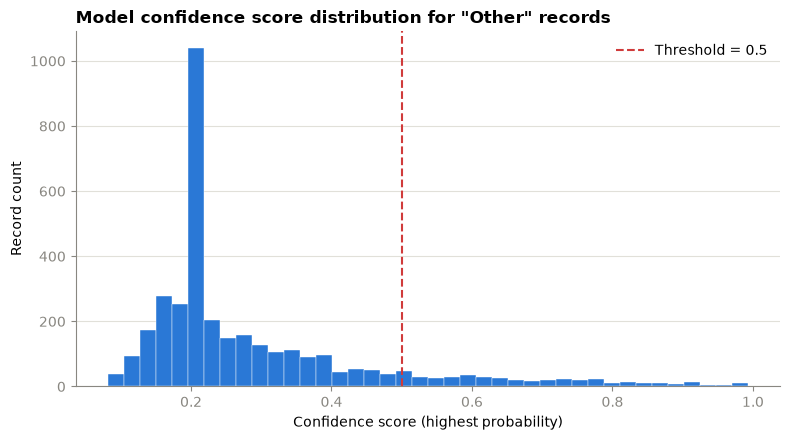

Records with confidence >= 0.5: 411 (11.6%)


In [10]:
COLOR_MAIN = '#2a78d6'
COLOR_CONFIDENT = '#1baf7a'
COLOR_MUTED = '#898781'
COLOR_TEXT = '#0b0b0b'
CONFIDENCE_THRESHOLD = 0.5

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df_other['confidence'], bins=40, color=COLOR_MAIN, edgecolor='white', linewidth=0.3)
ax.axvline(CONFIDENCE_THRESHOLD, color='#d03b3b', linewidth=1.5, linestyle='--',
           label=f'Threshold = {CONFIDENCE_THRESHOLD}')

ax.set_xlabel('Confidence score (highest probability)')
ax.set_ylabel('Record count')
ax.set_title('Model confidence score distribution for "Other" records', loc='left', fontsize=12, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='y', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)
ax.legend(frameon=False)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq5_other_confidence_distribution.png', dpi=150, bbox_inches='tight')

plt.show()

n_confident = (df_other['confidence'] >= CONFIDENCE_THRESHOLD).sum()
print(f'Records with confidence >= {CONFIDENCE_THRESHOLD}: {n_confident} ({n_confident/len(df_other)*100:.1f}%)')

In [11]:
confident_other = df_other[df_other['confidence'] >= CONFIDENCE_THRESHOLD]

print(f'Top 15 categories suggested by confident predictions (n={len(confident_other)}):')
print(confident_other['predicted_data_type'].value_counts().head(15))

Top 15 categories suggested by confident predictions (n=411):
predicted_data_type
Current session setting    218
Resource IDs                80
Search query                39
Query filter                35
User identifiers             6
URLs                         5
Ticker symbol                4
Date                         4
Email address                3
API key                      3
Text messages                2
State/province               2
Time period                  2
Multimedia data              2
Database information         2
Name: count, dtype: int64


**The most privacy-critical question:** how many of these confident predictions point to a **sensitive category** (at the `main_data_type` level)? In other words, are there records labeled "Other" that might actually be a sensitive data type? To check this we'll map each `data_type` value to the `main_data_type` it belongs to (almost every `data_type` maps to exactly one `main_data_type`).

In [12]:
SENSITIVE_CATEGORIES = ['Security credentials', 'Personal information', 'Health information', 'Finance information']

data_type_to_main = df_known.groupby('data_type')['main_data_type'].agg(lambda s: s.mode()[0])

confident_other = confident_other.copy()
confident_other['predicted_main_type'] = confident_other['predicted_data_type'].map(data_type_to_main)
confident_other['predicted_is_sensitive'] = confident_other['predicted_main_type'].isin(SENSITIVE_CATEGORIES)

n_sensitive_flagged = confident_other['predicted_is_sensitive'].sum()
print(f'Of the {len(confident_other)} confidently predicted "Other" records, '
      f'{n_sensitive_flagged} point to a sensitive category.')
print()
print('Suggested main_data_type distribution for these records:')
print(confident_other.loc[confident_other['predicted_is_sensitive'], 'predicted_main_type'].value_counts())

Of the 411 confidently predicted "Other" records, 7 point to a sensitive category.

Suggested main_data_type distribution for these records:
predicted_main_type
Security credentials    4
Personal information    3
Name: count, dtype: int64


In [13]:
sensitive_examples = confident_other[confident_other['predicted_is_sensitive']].sort_values('confidence', ascending=False)
sensitive_examples[['name', 'description', 'predicted_data_type', 'predicted_main_type', 'confidence']].head(10)

,name,description,predicted_data_type,predicted_main_type,confidence
874,email,,Email address,Personal information,0.909600
12055,email,Email of the vendor.,Email address,Personal information,0.898941
1721,key,,API key,Security credentials,0.822185
3086,skills,过滤 skill key,API key,Security credentials,0.822185
10025,KEY,,API key,Security credentials,0.822185
4287,token,Identifier of the token,Access tokens,Security credentials,0.506541
3971,email_type,The email type.,Email address,Personal information,0.503544


### Finding (Research Question 5)

**Answer: partially yes, but only for a small, carefully selected subset.**

- Only **11.6% (411 records)** of the 3,544 "Other" records cross the confidence threshold (50%). The large remaining majority leaves the model uncertain too — these records are probably genuinely ambiguous/general-purpose, and the "Other" label isn't unfair for them.
- Most confident predictions are already intuitive categories: general-purpose technical fields like `Current session setting`, `Resource IDs`, `Search query`.
- But **7 records** confidently point to a **sensitive category** (`Security credentials` or `Personal information`). Looking at the examples, this isn't surprising at all: records with `name="email"`, `name="key"`, `name="KEY"`, `name="token"` are suggested as "Email address" / "API key" / "Access tokens" with 82-91% confidence — in the original dataset these are labeled "Other," but their names alone make it obvious they're sensitive data.

**Overall conclusion:** the model can't reliably reclassify **all** "Other" records — but for a small subset (**high-confidence predictions**), it can catch genuinely mislabeled sensitive data types. A more sound practical use is to use this model not for "automatic relabeling" but for **generating a review-priority list** — the few hundred confidently predicted, sensitive-pointing records form a reasonable priority list for human review.

## Appendix — Privacy Policy Audit: Is the Collected Data Disclosed in the Policy?

**Note:** the `backend/final_results/` dataset used in this section was not produced by this project's own analysis pipeline — it was produced and published by the authors of the source paper (Wu, Y., Jaff, E., Yang, K., Zhang, N., & Iqbal, U. (2025). *An In-Depth Investigation of Data Collection in LLM App Ecosystems*. IMC '25. https://doi.org/10.1145/3730567.3732912), which is also the source of this project's main dataset and category taxonomy — see the project README's Data Sources & Attribution section. It's a separate, smaller source (381 plugin files) from the main dataset (12,811 records). In that work, each collected data parameter was compared against sentences extracted from that plugin's own privacy policy and labeled with one of five categories: `CLEAR` (clearly discloses), `VAGUE` (vaguely discloses), `AMBIGUOUS` (unclear whether it discloses), `INCORRECT` (incorrectly/misleadingly discloses), `OMITTED` (this sentence doesn't disclose it). What we do here is read this pre-labeled data and compute a parameter's overall disclosure status (based on its best-matching sentence, in that same priority order) — if no sentence discloses it, `UNDISCLOSED`.

Question: **Do plugins disclose what they collect in their privacy policies?**

In [14]:
from pathlib import Path
from collections import Counter

FINAL_RESULTS_DIR = Path('../backend/final_results')

def item_disclosure_status(item):
    """A parameter's disclosure status in the policy, based on its best (most explicit)
    labeled sentence — DISCLOSED_CLEAR if a CLEAR sentence exists, else DISCLOSED_VAGUE,
    else DISCLOSED_AMBIGUOUS, else DISCLOSED_INCORRECT, else UNDISCLOSED (if there is a
    comparable sentence at all). Priority order follows the source paper's own label
    ordering (CLEAR > VAGUE > AMBIGUOUS > INCORRECT > OMITTED)."""
    collection = item.get('collection') or []
    by_label = {}
    for c in collection:
        label = c.get('label')
        if label and label not in by_label:
            by_label[label] = c.get('sentence')
    for label, status in [('CLEAR', 'DISCLOSED_CLEAR'), ('VAGUE', 'DISCLOSED_VAGUE'),
                           ('AMBIGUOUS', 'DISCLOSED_AMBIGUOUS'), ('INCORRECT', 'DISCLOSED_INCORRECT')]:
        if label in by_label:
            return status
    if collection:
        return 'UNDISCLOSED'
    return 'NO_POLICY_TEXT'

status_counts = Counter()
for path in sorted(FINAL_RESULTS_DIR.glob('*.json')):
    try:
        items = json.loads(path.read_text(encoding='utf-8'))
    except (json.JSONDecodeError, UnicodeDecodeError):
        continue
    for item in items:
        status = item_disclosure_status(item)
        if status == 'NO_POLICY_TEXT':
            continue  # no comparable policy text exists for this parameter
        status_counts[status] += 1

total_audited = sum(status_counts.values())
print(f'Parameter count with comparable policy text: {total_audited}')
print(status_counts)

Parameter count with comparable policy text: 308
Counter({'UNDISCLOSED': 278, 'DISCLOSED_CLEAR': 16, 'DISCLOSED_VAGUE': 7, 'DISCLOSED_INCORRECT': 6, 'DISCLOSED_AMBIGUOUS': 1})


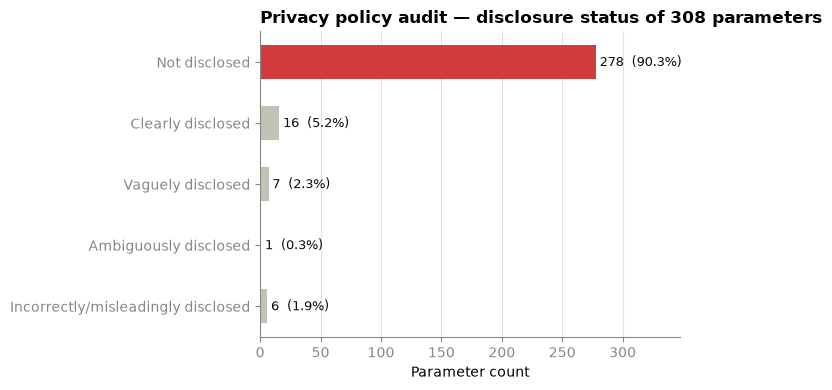

In [15]:
COLOR_SENSITIVE = '#d03b3b'
COLOR_NEUTRAL = '#c3c2b7'
COLOR_TEXT = '#0b0b0b'
COLOR_MUTED = '#898781'

labels_map = {
    'UNDISCLOSED': 'Not disclosed',
    'DISCLOSED_CLEAR': 'Clearly disclosed',
    'DISCLOSED_VAGUE': 'Vaguely disclosed',
    'DISCLOSED_AMBIGUOUS': 'Ambiguously disclosed',
    'DISCLOSED_INCORRECT': 'Incorrectly/misleadingly disclosed',
}
order = ['UNDISCLOSED', 'DISCLOSED_CLEAR', 'DISCLOSED_VAGUE', 'DISCLOSED_AMBIGUOUS', 'DISCLOSED_INCORRECT']
values = [status_counts[k] for k in order]
pcts = [v / total_audited * 100 for v in values]
colors = [COLOR_SENSITIVE if k == 'UNDISCLOSED' else COLOR_NEUTRAL for k in order]
labels = [labels_map[k] for k in order]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(labels[::-1], values[::-1], color=colors[::-1], height=0.55)

for bar, v, p in zip(bars, values[::-1], pcts[::-1]):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height() / 2, f'{v}  ({p:.1f}%)',
            va='center', ha='left', fontsize=9, color=COLOR_TEXT)

ax.set_xlabel('Parameter count')
ax.set_title(f'Privacy policy audit — disclosure status of {total_audited} parameters',
             loc='left', fontsize=12, fontweight='bold')
ax.set_xlim(0, max(values) * 1.25)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color(COLOR_MUTED)
ax.tick_params(colors=COLOR_MUTED)
ax.grid(axis='x', color='#e1e0d9', linewidth=0.8)
ax.set_axisbelow(True)

plt.tight_layout()

import os
os.makedirs('exported_charts', exist_ok=True)
plt.savefig('exported_charts/rq6_policy_disclosure.png', dpi=150, bbox_inches='tight')

plt.show()

## Summary — Part 3

**Research Question 4 answer:** clustering plugins by data-collection profile doesn't produce a clean "risky vs. safe" binary split. Instead, **functional/thematic clusters** emerge (finance & market, travel, e-commerce, location & weather, messaging & files, general-purpose, metadata-only) and sensitive-category density is spread **gradually** across them (between 0% and 16.1%). "Largest" and "riskiest" are different clusters: the two largest clusters (Cluster 0 + Cluster 8) make up ~80% of all plugins but have low-to-medium sensitive shares (1.5%, 12.5%); the two clusters with the highest sensitive share (Cluster 1 + Cluster 8) make up only ~32%. Practical takeaway: the clusters provide not a binary label but a **rankable risk score**.

**Research Question 5 answer:** we retrained Part 2's model without "Other" and applied it to the 3,544 "Other" records. The result is **partially positive**: only 11.6% of records can be confidently reclassified (≥50%) — most remain genuinely ambiguous. But within this small confident subset, **clearly sensitive** records like `name="email"`, `name="key"`, `name="token"` are correctly caught. The model can be used not for automatic relabeling, but for generating a **human-review priority list**.

## Overall Project Summary

**Project:** Privacy Risk Analysis and Automatic Classification in the GPT Plugin Ecosystem — 12,811 parameter records, 4,592 plugins, 25 coarse / 145 fine-grained data categories.

| # | Research Question | Answer |
|---|---|---|
| 1 | Category distribution, sensitive share? | Distribution is skewed (top-3 categories = 48.2%); the 4 sensitive categories make up **7.3%** of the total |
| 2 | Does the description-writing rate differ between sensitive/non-sensitive? | Statistically significant (p≈0.006) but the effect size is negligible (Cramér's V≈0.024) — no practical difference |
| 3 | Can category be predicted from name+description? | Yes, moderately: TF-IDF+LogReg **68.9% accuracy, 46.8% macro F1**; the embedding model generally trails but wins on rare classes; the model systematically defaults to "Other" |
| 4 | Do plugins naturally cluster into risky/safe groups? | No, no clean binary split — functional clusters emerge, sensitive share is spread gradually (0%–16.1%); the largest clusters (Cluster 0+8, ~80%) are not the same as the riskiest clusters (Cluster 1+8, ~32%) |
| 5 | Can the model classify "Other" records? | Partially — only 11.6% of records can be confidently relabeled, but this subset does catch genuine sensitive-data mislabelings (email, key, token) |

**Common theme:** the strongest recurring signal throughout the project is that the **"Other" category behaves like a catch-all bin** — the same pattern showed up in Part 2's classification report, its confusion matrix, and Part 3's "Other" reclassification attempt. This is the project's most important finding, both for data quality (labeling inconsistency) and model reliability.

**Methodological note:** because network access to Hugging Face was blocked by organizational policy in this environment, the embedding model used spaCy's GloVe-style word vectors instead of `sentence-transformers` — results should be interpreted with that substitution in mind.

**Limitations and future work:** (1) modeling over `data_type` had to group rare classes, which loses information; (2) clustering results are not sharply conclusive due to low silhouette scores; (3) the model applied to "Other" records couldn't be validated against ground truth (none exists) — findings are supported by qualitative examples but no systematic validation was performed; a real-world application should always route these predictions through human review; (4) in the RAG chatbot (Part B) that presents these analyses' results, the LLM can occasionally mix up correct numeric values from the context (e.g. the F1 scores of two similar categories, or two close but different statistics like "the largest cluster" vs. "the riskiest cluster") — even when the numbers are correct in the source context, there's a risk the LLM misstates them while rephrasing. Any numeric claim the chatbot produces should therefore be cross-checked against the original source in these notebooks, especially if it's going to support a publication or decision.